# 03 — SSL Pre-training + Fine-tuning (SimCLR)

Pre-train a SimCLR encoder on the unlabeled pool (ISIC 2018 + ISIC 2020),
then fine-tune on label fractions and compare AUC vs Label Budget against E2 baseline.

**Flag di controllo (unici punti da toccare):**
- `RUN_PRETRAINING` — True solo per rilancire il pretraining SSL
- `RUN_FINETUNE` — True per lanciare/ripetere il finetune su tutte le fractions
- `RUN_EVAL` — True per ricalcolare test_metrics.json su source e target


In [13]:
import os, sys, copy, json, torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import (
    evaluate_and_report, get_latest_run, plot_training_history,
    collect_auc_vs_fraction, collect_predictions, NumpyEncoder,
)
from src.trainers.simclr import run_ssl_pretraining, run_ssl_finetune
from src.utils import get_device, load_config
from src.metrics import compute_metrics, plot_auc_vs_labels
from data.scripts.make_label_subsets import FRACTIONS
from data.scripts.make_combined_csv import make_combined_csv

ALL_FRACTIONS = FRACTIONS + [1.0]  # [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
print('ALL_FRACTIONS:', ALL_FRACTIONS)

ALL_FRACTIONS: [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]


In [14]:
config = load_config('configs/simclr.yaml')
config

{'experiment': {'name': 'simclr_resnet18', 'seed': 42, 'device': 'auto'},
 'data': {'task': 'simclr',
  'train_csv': 'data/processed/combined_unlabeled.csv',
  'img_size': 224,
  'batch_size': 1024,
  'num_workers': 8},
 'model': {'arch': 'resnet18',
  'pretrained': True,
  'projection_dim': 128,
  'projection_hidden_dim': 512},
 'ssl': {'temperature': 0.07,
  'epochs': 100,
  'optimizer': 'adamw',
  'lr': 0.0003,
  'weight_decay': 0.0001,
  'save_every': 10,
  'save_best': True},
 'finetune': {'epochs': 30,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs_low': 5,
  'freeze_backbone_epochs_high': 0},
 'finetune_data': {'batch_size': 64, 'num_workers': 4},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'early_stopping': {'monitor': 'val_auc', 'patience': 7, 'min_delta': 0.0},
 'logging': {'save_dir': 'results/runs'}}

In [15]:
combined_csv = Path(config['data']['train_csv'])
if not combined_csv.exists():
    print('combined_unlabeled.csv non trovato, lo genero...')
    make_combined_csv()
    print('Done.')
else:
    print(f'OK: {combined_csv} ({len(open(combined_csv).readlines())-1} righe)')

OK: data/processed/combined_unlabeled.csv (34512 righe)


## 1. SSL Pretraining


In [16]:
RUN_PRETRAINING = False

pretrain_exp_name = config['experiment']['name']  # 'simclr_resnet18'

if RUN_PRETRAINING:
    ssl_ckpt_path = run_ssl_pretraining(config)
else:
    run_dir_ssl = get_latest_run(pretrain_exp_name)
    if run_dir_ssl is None:
        raise FileNotFoundError(
            f"Nessun run trovato per '{pretrain_exp_name}'.\n"
            "Opzioni:\n"
            "  1. Imposta RUN_PRETRAINING = True\n"
            "  2. Scarica il checkpoint e mettilo in:\n"
            "     results/runs/simclr_resnet18/<timestamp>/checkpoints/encoder_best.pt"
        )
    ssl_ckpt_path = str(run_dir_ssl / 'checkpoints/encoder_best.pt')
    if not Path(ssl_ckpt_path).exists():
        raise FileNotFoundError(f'encoder_best.pt non trovato in {run_dir_ssl}')

print('Encoder checkpoint:', ssl_ckpt_path)

Encoder checkpoint: results/runs/simclr_resnet18/20260601_095217/checkpoints/encoder_best.pt


## 2. SSL Pretraining — curva di loss


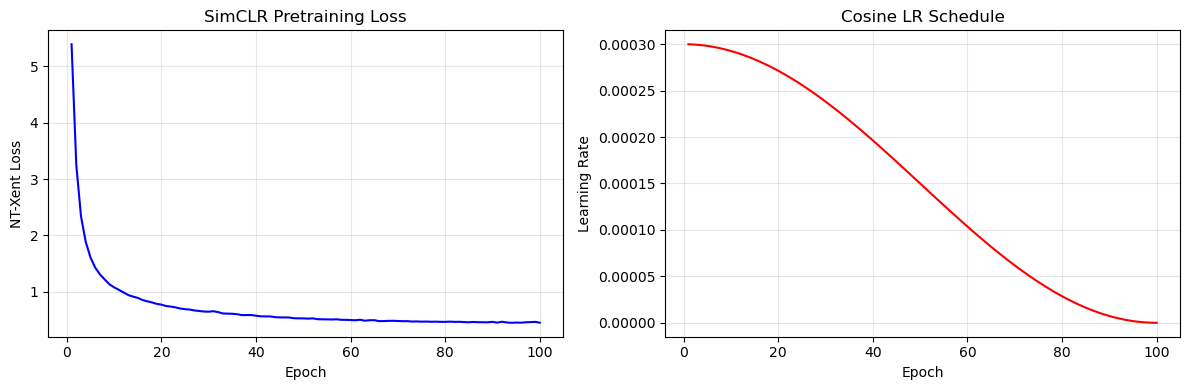

Best epoch: 94 | Best loss: 0.4486


In [17]:
run_dir_ssl = Path(ssl_ckpt_path).parent.parent
metrics_path_ssl = run_dir_ssl / 'metrics.jsonl'

epochs_list, losses, lrs = [], [], []
for line in metrics_path_ssl.read_text().strip().split('\n'):
    if not line.strip(): continue
    e = json.loads(line)
    epochs_list.append(e['epoch']); losses.append(e['ssl_loss']); lrs.append(e['lr'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_list, losses, 'b-', linewidth=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('NT-Xent Loss')
ax1.set_title('SimCLR Pretraining Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(epochs_list, lrs, 'r-', linewidth=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
ax2.set_title('Cosine LR Schedule'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
fig_dir = Path('results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / 'ssl_pretrain_loss.png', dpi=150, bbox_inches='tight')
plt.show()
best_e = min((json.loads(l) for l in metrics_path_ssl.read_text().strip().split('\n') if l.strip()), key=lambda x: x['ssl_loss'])
print(f"Best epoch: {best_e['epoch']} | Best loss: {best_e['ssl_loss']:.4f}")

## 3. Fine-tuning su tutte le fractions (inclusa 1.00)

Fractions: 1%, 5%, 10%, 25%, 50%, 100%.
Il loop salta i run gia completi (checkpoint + test_metrics.json entrambi presenti) se `RUN_FINETUNE=False`.


In [18]:
RUN_FINETUNE = False  # True per forzare il rifinetune anche se gia esistono

exp_name_prefix_ssl = 'simclr_ft_{:.2f}'

for fraction in ALL_FRACTIONS:
    exp_name = exp_name_prefix_ssl.format(fraction)
    run_dir_ft = get_latest_run(exp_name)
    has_ckpt = run_dir_ft is not None and (run_dir_ft / 'checkpoints/best.pt').exists()

    if has_ckpt and not RUN_FINETUNE:
        print(f'[SKIP] {exp_name} — checkpoint gia presente')
        continue

    print(f"\n{'='*55}")
    print(f'Fine-tuning | fraction={fraction:.2f}')
    print(f"{'='*55}")
    result = run_ssl_finetune(
        base_config=config,
        ssl_ckpt_path=ssl_ckpt_path,
        fraction=fraction,
    )
    print(f"[OK] best_val_auc={result['best_val_auc']:.4f} | dir={result['run_dir']}")

print('\nFine-tuning completato.')

[SKIP] simclr_ft_0.01 — checkpoint gia presente
[SKIP] simclr_ft_0.05 — checkpoint gia presente
[SKIP] simclr_ft_0.10 — checkpoint gia presente
[SKIP] simclr_ft_0.25 — checkpoint gia presente
[SKIP] simclr_ft_0.50 — checkpoint gia presente
[SKIP] simclr_ft_1.00 — checkpoint gia presente

Fine-tuning completato.


## 4. Valutazione su source (ISIC 2018) e target (ISIC 2020)

Carica `best.pt` da ogni run, valuta su entrambi i test set.
Salva `test_metrics.json` (source) e `test_metrics_isic2020.json` (target).
Salta se i file esistono gia e `RUN_EVAL=False`.


In [19]:
RUN_EVAL = True  # True per forzare ricalcolo anche se i file esistono

device = get_device(config['experiment'].get('device', 'auto'))
print(f'Device: {device}')

for fraction in ALL_FRACTIONS:
    exp_name = exp_name_prefix_ssl.format(fraction)
    run_dir_ft = get_latest_run(exp_name)
    if run_dir_ft is None:
        print(f'[SKIP] {exp_name}: run non trovato')
        continue
    ckpt_path = run_dir_ft / 'checkpoints/best.pt'
    if not ckpt_path.exists():
        print(f'[SKIP] {exp_name}: best.pt mancante')
        continue

    src_metrics_path = run_dir_ft / 'test_metrics.json'
    tgt_metrics_path = run_dir_ft / 'test_metrics_isic2020.json'
    both_exist = src_metrics_path.exists() and tgt_metrics_path.exists()
    if both_exist and not RUN_EVAL:
        src_auc = json.load(open(src_metrics_path)).get('auc_roc', '?')
        tgt_auc = json.load(open(tgt_metrics_path)).get('auc_roc', '?')
        print(f'[SKIP] {exp_name}: src={src_auc:.4f} tgt={tgt_auc:.4f} (cached)')
        continue

    # Carica config salvato nel run per usare i path corretti
    run_cfg = load_config(str(run_dir_ft / 'config.yaml'))

    # Costruisci modello con pesi finetuned
    model = build_backbone(
        arch=run_cfg['model']['arch'],
        pretrained=False,
        num_classes=run_cfg['model'].get('num_classes', 1),
    )
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.to(device)

    def _eval_and_save(csv_path, out_path):
        cfg = copy.deepcopy(run_cfg)
        cfg['data']['task'] = 'supervised'
        cfg['data']['test_csv'] = csv_path
        cfg['data']['train_csv'] = 'data/processed/isic2018/train.csv'
        loader = build_loaders(cfg)['test']
        y_true, y_proba = collect_predictions(model, loader, device)
        metrics = compute_metrics(y_true, y_proba)
        with open(out_path, 'w') as fp:
            json.dump(metrics, fp, indent=2, cls=NumpyEncoder)
        return metrics['auc_roc']

    src_auc = _eval_and_save('data/processed/isic2018/test.csv', src_metrics_path)
    tgt_auc = _eval_and_save('data/processed/isic2020/test.csv', tgt_metrics_path)
    print(f'[DONE] {exp_name}: src={src_auc:.4f} tgt={tgt_auc:.4f}')

print('\nValutazione completata.')

Device: mps
[DONE] simclr_ft_0.01: src=0.8451 tgt=0.7984
[DONE] simclr_ft_0.05: src=0.8730 tgt=0.6736
[DONE] simclr_ft_0.10: src=0.8699 tgt=0.6559
[DONE] simclr_ft_0.25: src=0.8836 tgt=0.6144
[DONE] simclr_ft_0.50: src=0.9090 tgt=0.6817
[DONE] simclr_ft_1.00: src=0.9340 tgt=0.6939

Valutazione completata.


## 5. Raccolta AUC vs Label Budget


In [20]:
def _read_auc(run_dir, filename):
    p = run_dir / filename
    if p.exists():
        return json.load(open(p)).get('auc_roc')
    return None

# ── SSL ────────────────────────────────────────────────────────────────
aucs_2018_ssl, aucs_2020_ssl = {}, {}
for f in ALL_FRACTIONS:
    rd = get_latest_run(exp_name_prefix_ssl.format(f))
    aucs_2018_ssl[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_ssl[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Baseline fractions 1%–50% ──────────────────────────────────────────
exp_name_prefix_base = 'baseline_resnet18_{:.2f}'
aucs_2018_base, aucs_2020_base = {}, {}
for f in FRACTIONS:  # senza 1.0 — la full e' separata
    rd = get_latest_run(exp_name_prefix_base.format(f))
    aucs_2018_base[f] = _read_auc(rd, 'test_metrics.json') if rd else None
    aucs_2020_base[f] = _read_auc(rd, 'test_metrics_isic2020.json') if rd else None

# ── Baseline full (100%) ───────────────────────────────────────────────
rd_full = get_latest_run('baseline_resnet18_full')
aucs_2018_base[1.0] = _read_auc(rd_full, 'test_metrics.json') if rd_full else None
aucs_2020_base[1.0] = _read_auc(rd_full, 'test_metrics_isic2020.json') if rd_full else None

print('SSL   source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_ssl.items() if v})
print('SSL   target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_ssl.items() if v})
print('Base  source:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2018_base.items() if v})
print('Base  target:', {f'{k*100:.0f}%': round(v,4) for k,v in aucs_2020_base.items() if v})

SSL   source: {'1%': 0.8451, '5%': 0.873, '10%': 0.8699, '25%': 0.8836, '50%': 0.909, '100%': 0.934}
SSL   target: {'1%': 0.7984, '5%': 0.6736, '10%': 0.6559, '25%': 0.6144, '50%': 0.6817, '100%': 0.6939}
Base  source: {'1%': 0.8138, '5%': 0.8629, '10%': 0.8631, '25%': 0.8679, '50%': 0.9065, '100%': 0.9181}
Base  target: {'1%': 0.6619, '5%': 0.7118, '10%': 0.6853, '25%': 0.6294, '50%': 0.6353, '100%': 0.6975}


## 6. Plot AUC vs Label Budget — SSL vs Baseline


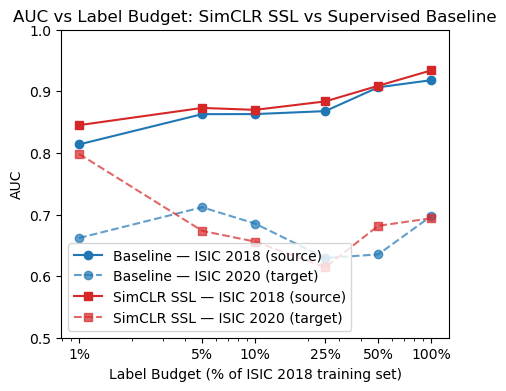

Figura salvata in results/figures/auc_vs_labels_ssl_vs_baseline.png


In [21]:
results = {
    'Baseline — ISIC 2018 (source)': {f: v for f, v in aucs_2018_base.items() if v is not None},
    'Baseline — ISIC 2020 (target)': {f: v for f, v in aucs_2020_base.items() if v is not None},
    'SimCLR SSL — ISIC 2018 (source)': {f: v for f, v in aucs_2018_ssl.items() if v is not None},
    'SimCLR SSL — ISIC 2020 (target)': {f: v for f, v in aucs_2020_ssl.items() if v is not None},
}
style_map = {
    'Baseline — ISIC 2018 (source)':    {'color': 'tab:blue',   'linestyle': '-',  'marker': 'o'},
    'Baseline — ISIC 2020 (target)':    {'color': 'tab:blue',   'linestyle': '--', 'marker': 'o', 'alpha': 0.7},
    'SimCLR SSL — ISIC 2018 (source)':  {'color': 'tab:red',    'linestyle': '-',  'marker': 's'},
    'SimCLR SSL — ISIC 2020 (target)':  {'color': 'tab:red',    'linestyle': '--', 'marker': 's', 'alpha': 0.7},
}
out_path = 'results/figures/auc_vs_labels_ssl_vs_baseline.png'
fig = plot_auc_vs_labels(
    results,
    save_path=out_path,
    x_scale='log',
    x_as_percent=True,
    title='AUC vs Label Budget: SimCLR SSL vs Supervised Baseline',
    ylim=(0.5, 1.0),
    style_map=style_map,
)
plt.show()
print(f'Figura salvata in {out_path}')

## 7. Training history per fraction


In [22]:
for fraction in ALL_FRACTIONS:
    exp_name = exp_name_prefix_ssl.format(fraction)
    rd = get_latest_run(exp_name)
    if rd is None:
        print(f'[SKIP] {exp_name}: run non trovato')
        continue
    save_path = str(rd / 'figures/training_history.png')
    plot_training_history(rd, save_path=save_path)
    print(f'fraction={fraction:.2f} | salvato in {save_path}')

fraction=0.01 | salvato in results/runs/simclr_ft_0.01/20260601_143001/figures/training_history.png
fraction=0.05 | salvato in results/runs/simclr_ft_0.05/20260601_153436/figures/training_history.png
fraction=0.10 | salvato in results/runs/simclr_ft_0.10/20260601_164605/figures/training_history.png
fraction=0.25 | salvato in results/runs/simclr_ft_0.25/20260601_170726/figures/training_history.png
fraction=0.50 | salvato in results/runs/simclr_ft_0.50/20260601_172936/figures/training_history.png
fraction=1.00 | salvato in results/runs/simclr_ft_1.00/20260602_020334/figures/training_history.png


## 8. Summary table


In [23]:
def _s(d, f):
    v = d.get(f)
    return round(v, 4) if v is not None else float('nan')

rows = []
for f in ALL_FRACTIONS:
    b_src = _s(aucs_2018_base, f)
    b_tgt = _s(aucs_2020_base, f)
    s_src = _s(aucs_2018_ssl,  f)
    s_tgt = _s(aucs_2020_ssl,  f)
    rows.append({
        'fraction':          f'{f*100:.0f}%',
        'base_src_auc':      b_src,
        'base_tgt_auc':      b_tgt,
        'ssl_src_auc':       s_src,
        'ssl_tgt_auc':       s_tgt,
        'delta_src':         round(s_src - b_src, 4),
        'delta_tgt':         round(s_tgt - b_tgt, 4),
    })

df = pd.DataFrame(rows).set_index('fraction')
print(df.to_string())
Path('results/metrics').mkdir(parents=True, exist_ok=True)
df.to_csv('results/metrics/ssl_vs_baseline.csv')
print('\nSalvato in results/metrics/ssl_vs_baseline.csv')

          base_src_auc  base_tgt_auc  ssl_src_auc  ssl_tgt_auc  delta_src  delta_tgt
fraction                                                                            
1%              0.8138        0.6619       0.8451       0.7984     0.0313     0.1365
5%              0.8629        0.7118       0.8730       0.6736     0.0101    -0.0382
10%             0.8631        0.6853       0.8699       0.6559     0.0068    -0.0294
25%             0.8679        0.6294       0.8836       0.6144     0.0157    -0.0150
50%             0.9065        0.6353       0.9090       0.6817     0.0025     0.0464
100%            0.9181        0.6975       0.9340       0.6939     0.0159    -0.0036

Salvato in results/metrics/ssl_vs_baseline.csv


## 9. Diagnostica — val_auc massimo per run


In [24]:
print(f"{'Fraction':>10} | {'Base val_auc_max':>16} | {'SSL val_auc_max':>15}")
print('-' * 50)

for f in ALL_FRACTIONS:
    def _max_val_auc(exp_name):
        rd = get_latest_run(exp_name)
        if rd is None or not (rd / 'metrics.jsonl').exists():
            return None
        lines = (rd / 'metrics.jsonl').read_text().strip().split('\n')
        aucs = [json.loads(l).get('val_auc') for l in lines if l.strip()]
        aucs = [a for a in aucs if a is not None]
        return round(max(aucs), 4) if aucs else None

    if f < 1.0:
        b_val = _max_val_auc(f'baseline_resnet18_{f:.2f}')
    else:
        b_val = _max_val_auc('baseline_resnet18_full')
    s_val = _max_val_auc(f'simclr_ft_{f:.2f}')

    b_str = f'{b_val:.4f}' if b_val else 'N/A'
    s_str = f'{s_val:.4f}' if s_val else 'N/A'
    print(f"{f*100:>9.0f}% | {b_str:>16} | {s_str:>15}")

  Fraction | Base val_auc_max | SSL val_auc_max
--------------------------------------------------
        1% |           0.7799 |          0.7829
        5% |           0.8355 |          0.8496
       10% |           0.8709 |          0.8640
       25% |           0.8808 |          0.8673
       50% |           0.9137 |          0.8969
      100% |           0.9279 |          0.9319
